In [13]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")

batch_size = 128
epochs = 1000



## Data handling

In [14]:
data = pd.read_csv("./data/data_lab3/data_lab3v04.csv", header=None)
data.columns = ["x1", "x2", "y"]
data

,x1,x2,y
0,1.4703,1.45800,1
1,5.3021,0.98959,1
2,3.8676,1.84660,1
3,3.3552,3.24970,1
4,-1.8971,2.05400,1
...,...,...,...
595,5.4514,1.12580,4
596,4.9265,2.11520,4
597,6.2956,1.41230,4
598,6.1591,3.10520,4


In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      600 non-null    float64
 1   x2      600 non-null    float64
 2   y       600 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 14.2 KB


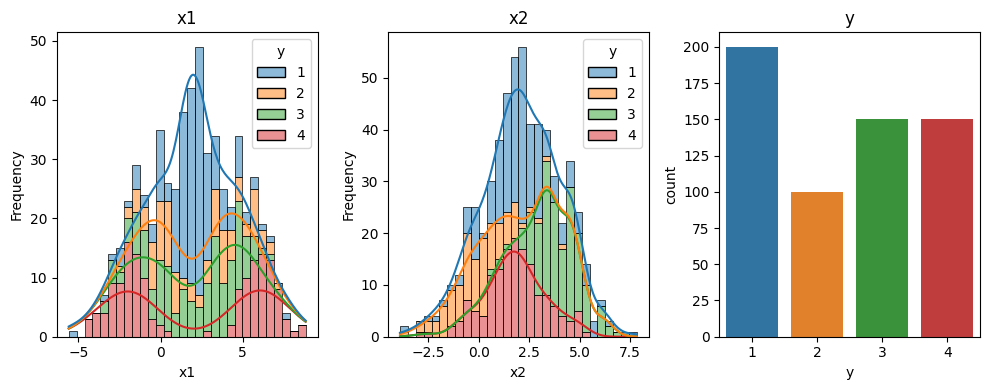

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

class_order = sorted(data["y"].unique())
palette = dict(zip(class_order, sns.color_palette("tab10", n_colors=len(class_order))))

sns.histplot(
    data=data,
    x="x1",
    hue="y",
    hue_order=class_order,
    bins=30,
    palette=palette,
    multiple="stack",
    kde=True,
    ax=axes[0],
)
axes[0].set_title("x1")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("Frequency")

sns.histplot(
    data=data,
    x="x2",
    hue="y",
    hue_order=class_order,
    bins=30,
    palette=palette,
    multiple="stack",
    kde=True,
    ax=axes[1],
)
axes[1].set_title("x2")
axes[1].set_xlabel("x2")
axes[1].set_ylabel("Frequency")

counts = data["y"].value_counts().sort_index()
count_df = counts.reset_index()
count_df.columns = ["y", "count"]
sns.barplot(
    data=count_df,
    x="y",
    y="count",
    hue="y",
    hue_order=class_order,
    palette=palette,
    dodge=False,
    legend=False,
    ax=axes[2],
)
axes[2].set_title("y")
axes[2].set_xlabel("y")

plt.tight_layout()
plt.show()

<Axes: xlabel='x1', ylabel='x2'>

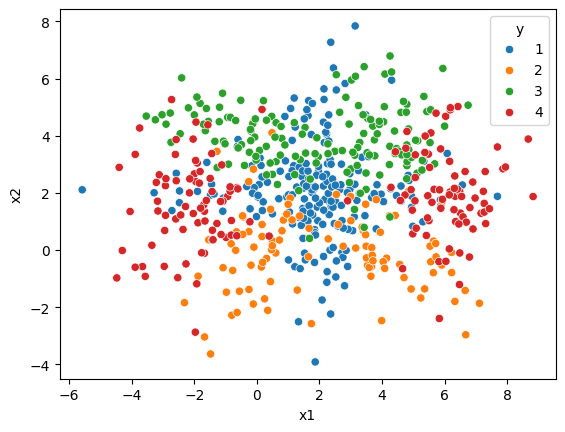

In [17]:
sns.scatterplot(
    x=data["x1"],
    y=data["x2"],
    hue=data["y"],
    hue_order=class_order,
    palette=palette,
)


In [18]:
def train_test_val_split(data, ratio, random_state=42):
    if len(ratio) != 3:
        raise ValueError("ratio must contain exactly 3 values: (train, val, test)")

    train_ratio, val_ratio, test_ratio = ratio

    if any(r < 0 for r in ratio):
        raise ValueError("all ratio values must be non-negative")

    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("ratio values must sum to 1")

    stratify_target = data["y"] if "y" in data.columns else None

    train_data, remainder = train_test_split(
        data,
        test_size=(1 - train_ratio),
        random_state=random_state,
        stratify=stratify_target,
    )

    if np.isclose(val_ratio, 0.0):
        val_data = data.iloc[0:0].copy()
        test_data = remainder
    elif np.isclose(test_ratio, 0.0):
        val_data = remainder
        test_data = data.iloc[0:0].copy()
    else:
        val_share_in_remainder = val_ratio / (val_ratio + test_ratio)
        remainder_stratify = remainder["y"] if "y" in remainder.columns else None

        val_data, test_data = train_test_split(
            remainder,
            test_size=(1 - val_share_in_remainder),
            random_state=random_state,
            stratify=remainder_stratify,
        )

    return (
        train_data.reset_index(drop=True),
        val_data.reset_index(drop=True),
        test_data.reset_index(drop=True),
    )

train, val, test = train_test_val_split(data, [0.6, 0.3, 0.1])

In [19]:
scaler = StandardScaler()

train[["x1", "x2"]] = scaler.fit_transform(train[["x1", "x2"]])
val[["x1", "x2"]] = scaler.transform(val[["x1", "x2"]])
test[["x1", "x2"]] = scaler.transform(test[["x1", "x2"]])

train[["y1", "y2", "y3", "y4"]] = pd.get_dummies(train["y"])
val[["y1", "y2", "y3", "y4"]] = pd.get_dummies(val["y"])
test[["y1", "y2", "y3", "y4"]] = pd.get_dummies(test["y"])

train

,x1,x2,y,y1,y2,y3,y4
0,-0.913410,-0.792036,4,False,False,False,True
1,0.682566,-0.145124,2,False,True,False,False
2,-0.757198,1.113117,3,False,False,True,False
3,-1.834702,0.163331,4,False,False,False,True
4,1.156649,0.908999,3,False,False,True,False
...,...,...,...,...,...,...,...
355,-1.384796,0.555696,4,False,False,False,True
356,-0.825836,0.466871,3,False,False,True,False
357,-1.500236,-0.267994,4,False,False,False,True
358,0.391547,-0.521568,2,False,True,False,False


In [20]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.tensor(train[["x1", "x2"]].values), torch.tensor(train[["y1", "y2", "y3", "y4"]].values))
val_dataset = TensorDataset(torch.tensor(val[["x1", "x2"]].values), torch.tensor(val[["y1", "y2", "y3", "y4"]].values))
test_dataset = TensorDataset(torch.tensor(test[["x1", "x2"]].values))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training

In [21]:
import torch.nn as nn
import torch.optim as optim

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(2, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 4),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        return self.linear(x)

model = NeuralNetwork()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

model

NeuralNetwork(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=4, bias=True)
    (5): Softmax(dim=1)
  )
)

Training: 100%|██████████| 1000/1000 [00:12<00:00, 81.66it/s]


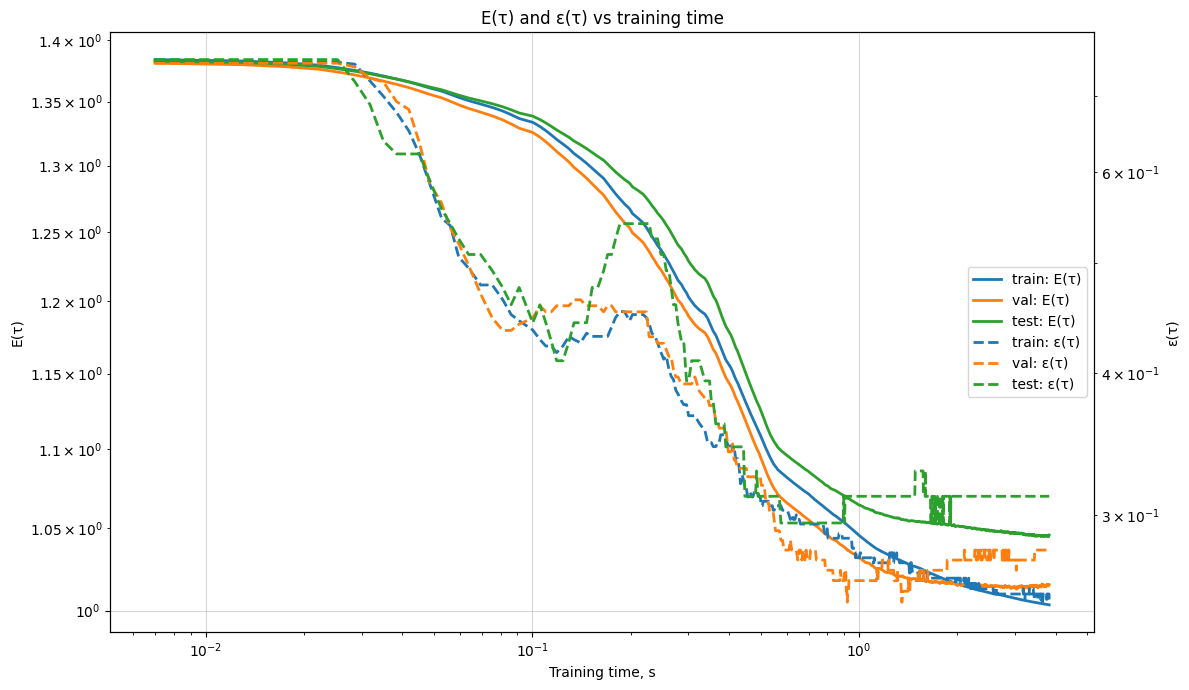

Mean loss: train - 1.0034, val - 1.0153, test - 1.0455
Mean error: train - 0.2528, val - 0.2793, test - 0.3115


In [22]:
# Powered by cursor

import copy
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


def evaluate_epoch(net, loader, criterion_fn, device):
    net.eval()
    loss_sum = 0.0
    batches = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device=device, dtype=torch.float32)
            y_batch = y_batch.to(device=device, dtype=torch.float32)

            probs = net(x_batch)
            loss = criterion_fn(probs, y_batch)

            loss_sum += loss.item()
            batches += 1

            pred_class = probs.argmax(dim=1)
            true_class = y_batch.argmax(dim=1)
            correct += (pred_class == true_class).sum().item()
            total += y_batch.size(0)

    mean_loss = loss_sum / max(batches, 1)
    cls_error = 1.0 - (correct / max(total, 1))
    return mean_loss, cls_error


# Labeled loaders for train/validation/test metrics.
train_eval_dataset = TensorDataset(
    torch.tensor(train[["x1", "x2"]].values, dtype=torch.float32),
    torch.tensor(train[["y1", "y2", "y3", "y4"]].values, dtype=torch.float32),
)
val_eval_dataset = TensorDataset(
    torch.tensor(val[["x1", "x2"]].values, dtype=torch.float32),
    torch.tensor(val[["y1", "y2", "y3", "y4"]].values, dtype=torch.float32),
)
test_eval_dataset = TensorDataset(
    torch.tensor(test[["x1", "x2"]].values, dtype=torch.float32),
    torch.tensor(test[["y1", "y2", "y3", "y4"]].values, dtype=torch.float32),
)

train_eval_loader = DataLoader(train_eval_dataset, batch_size=batch_size, shuffle=False)
val_eval_loader = DataLoader(val_eval_dataset, batch_size=batch_size, shuffle=False)
test_eval_loader = DataLoader(test_eval_dataset, batch_size=batch_size, shuffle=False)

n_epochs = int(epochs) if "epochs" in globals() else 100

# Reuse criterion and optimizer setup from notebook cell with criterion/optimizer definition.
net_for_plot = NeuralNetwork().to(device)
criterion_for_plot = copy.deepcopy(criterion)
optimizer_for_plot = type(optimizer)(net_for_plot.parameters(), **optimizer.defaults)

history = {
    "time": [],
    "train_loss": [], "train_err": [],
    "val_loss": [], "val_err": [],
    "test_loss": [], "test_err": [],
}

elapsed = 0.0
for _ in tqdm(range(n_epochs), desc="Training"):
    net_for_plot.train()
    start = time.perf_counter()

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device=device, dtype=torch.float32)
        y_batch = y_batch.to(device=device, dtype=torch.float32)

        optimizer_for_plot.zero_grad()
        probs = net_for_plot(x_batch)
        loss = criterion_for_plot(probs, y_batch)
        loss.backward()
        optimizer_for_plot.step()

    elapsed += time.perf_counter() - start
    history["time"].append(elapsed)

    tr_loss, tr_err = evaluate_epoch(net_for_plot, train_eval_loader, criterion_for_plot, device)
    va_loss, va_err = evaluate_epoch(net_for_plot, val_eval_loader, criterion_for_plot, device)
    te_loss, te_err = evaluate_epoch(net_for_plot, test_eval_loader, criterion_for_plot, device)

    history["train_loss"].append(tr_loss)
    history["train_err"].append(tr_err)
    history["val_loss"].append(va_loss)
    history["val_err"].append(va_err)
    history["test_loss"].append(te_loss)
    history["test_err"].append(te_err)


# One chart: 3 colors for datasets, 2 line types for metrics.
t = np.array(history["time"])
colors = {
    "train": "tab:blue",
    "val": "tab:orange",
    "test": "tab:green",
}

fig, ax_loss = plt.subplots(figsize=(12, 7))
ax_err = ax_loss.twinx()

for split in ["train", "val", "test"]:
    ax_loss.loglog(
        t,
        history[f"{split}_loss"],
        color=colors[split],
        linestyle="-",
        linewidth=2,
        label=f"{split}: E(τ)",
    )
    ax_err.loglog(
        t,
        history[f"{split}_err"],
        color=colors[split],
        linestyle="--",
        linewidth=2,
        label=f"{split}: ε(τ)",
    )

ax_loss.set_title("E(τ) and ε(τ) vs training time")
ax_loss.set_xlabel("Training time, s")
ax_loss.set_ylabel("E(τ)")
ax_err.set_ylabel("ε(τ)")
ax_loss.grid(alpha=0.5)

loss_handles, loss_labels = ax_loss.get_legend_handles_labels()
err_handles, err_labels = ax_err.get_legend_handles_labels()
ax_loss.legend(loss_handles + err_handles, loss_labels + err_labels, loc="center right")

plt.tight_layout()
plt.show()

print(f"Mean loss: train - {tr_loss:.4f}, val - {va_loss:.4f}, test - {te_loss:.4f}")
print(f"Mean error: train - {tr_err:.4f}, val - {va_err:.4f}, test - {te_err:.4f}")

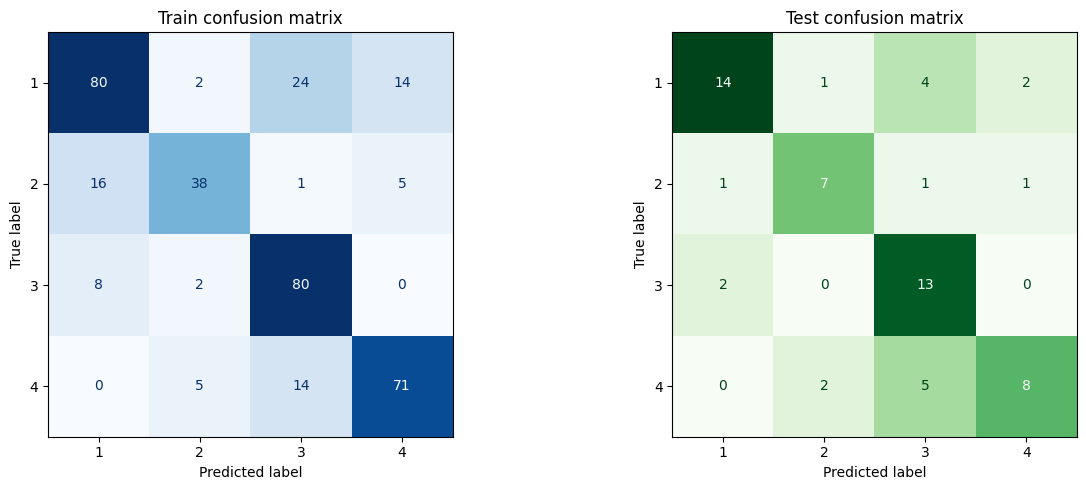

In [23]:
# Powered by cursor

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def collect_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device=device, dtype=torch.float32)
            probs = model(x_batch)

            y_true.append(y_batch.argmax(dim=1).cpu().numpy())
            y_pred.append(probs.argmax(dim=1).cpu().numpy())

    return np.concatenate(y_true), np.concatenate(y_pred)


train_true, train_pred = collect_predictions(net_for_plot, train_eval_loader, device)
test_true, test_pred = collect_predictions(net_for_plot, test_eval_loader, device)

class_labels = [str(i + 1) for i in range(train_true.max() + 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(train_true, train_pred),
    display_labels=class_labels,
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Train confusion matrix")

ConfusionMatrixDisplay(
    confusion_matrix(test_true, test_pred),
    display_labels=class_labels,
).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Test confusion matrix")

plt.tight_layout()
plt.show()

/Users/andrey/Ground/Neural_networks/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


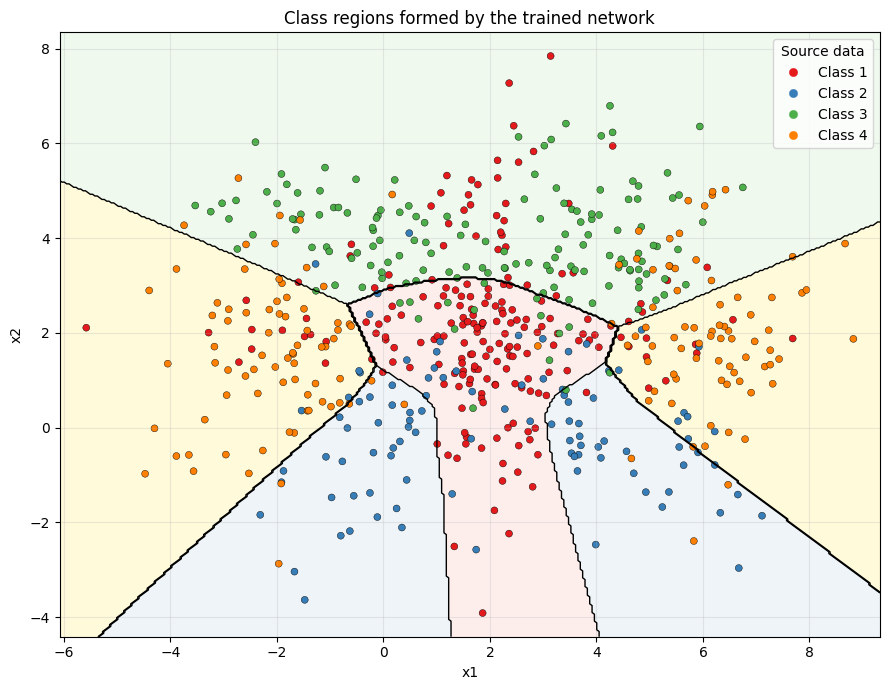

In [24]:
# Powered by cursor

from matplotlib.colors import ListedColormap

# Decision regions of the trained network in original feature space
x_raw = data[["x1", "x2"]].values
y_raw = data["y"].to_numpy()
classes = np.sort(np.unique(y_raw))
class_to_idx = {cls: i for i, cls in enumerate(classes)}

x1_min, x1_max = x_raw[:, 0].min() - 0.5, x_raw[:, 0].max() + 0.5
x2_min, x2_max = x_raw[:, 1].min() - 0.5, x_raw[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 350),
    np.linspace(x2_min, x2_max, 350),
)

grid_raw = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid_raw)

grid_tensor = torch.tensor(grid_scaled, dtype=torch.float32, device=device)

net_for_plot.eval()
with torch.no_grad():
    pred_idx = net_for_plot(grid_tensor).argmax(dim=1).cpu().numpy()

pred_classes = classes[pred_idx]
pred_regions = np.vectorize(class_to_idx.get)(pred_classes).reshape(xx.shape)
point_colors = np.vectorize(class_to_idx.get)(y_raw)

region_cmap = ListedColormap(["#fde0dd", "#e0ecf4", "#e5f5e0", "#fff7bc"][: len(classes)])
point_cmap = ListedColormap(["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00"][: len(classes)])

fig, ax = plt.subplots(figsize=(9, 7))

ax.contourf(
    xx,
    yy,
    pred_regions,
    levels=np.arange(len(classes) + 1) - 0.5,
    cmap=region_cmap,
    alpha=0.55,
)

# Draw boundaries between predicted classes
ax.contour(
    xx,
    yy,
    pred_regions,
    levels=np.arange(len(classes) - 1) + 0.5,
    colors="black",
    linewidths=1.0,
)

scatter = ax.scatter(
    x_raw[:, 0],
    x_raw[:, 1],
    c=point_colors,
    cmap=point_cmap,
    edgecolor="k",
    linewidth=0.3,
    s=25,
)

handles, _ = scatter.legend_elements()
ax.legend(handles, [f"Class {cls}" for cls in classes], title="Source data", loc="best")
ax.set_title("Class regions formed by the trained network")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()